MATH 60629A
======
Tutorial: A Practical Introduction to Machine Learning in Python
=============

Imagine you have just been hired as a data analyst at a bike-sharing company (think [BIXI](https://bixi.com/en/)). The operations team comes to you with two requests:

1. **Forecast demand:** how many bikes will be rented at a given hour? (This drives maintenance and rebalancing plans.)
2. **Flag high-demand hours in advance**, so that trucks can pre-position bikes at busy stations.

The first is a **regression** problem, the second a **classification** problem — precisely the two families of supervised learning we studied in weeks 2 and 3. In this tutorial you will solve both, on real data, using the standard Python toolkit:

- **NumPy** — arrays of numbers and fast math on them ([Part 1](#numpy)),
- **pandas** — tables of data ([Part 2](#pandas)),
- **scikit-learn** — the machine learning models themselves ([Parts 3](#regression) and [4](#classification)).

Our data comes from Capital Bikeshare (Washington, DC): every hour of operation in 2011–2012, together with the weather and calendar information for that hour.

**How to use this notebook.**
- Run cells one by one, from top to bottom, with `Shift+Enter`.
- Exercises are marked with ✏️. They are short and meant to be done as you go: replace the `...` with your own code.
- **Part 1 (NumPy) is optional**: if you are already comfortable with arrays, skip directly to [Part 2](#pandas).
- Approximate timing for our 180 minutes: Part 1 (15 min) · Part 2 (30 min) · Part 3 (50 min) · Part 4 (45 min) · Part 5 (30 min).

**Table of contents**
- [Part 0 — Setup](#setup)
- [Part 1 — NumPy in 15 minutes (optional)](#numpy)
- [Part 2 — Just enough pandas](#pandas)
- [Part 3 — Regression: predicting hourly demand](#regression)
- [Part 4 — Classification: flagging high-demand hours](#classification)
- [Part 5 — Challenge: beat our best model](#challenge)
- [Epilogue — A glimpse of next week](#epilogue)

<a id='setup'></a>
# Part 0 — Setup

This notebook runs on [Google Colab](https://colab.research.google.com/) or on your own machine. The cell below downloads the two files we need (the dataset and a small helper file for plots) if they are not already present.

In [1]:
import os
import urllib.request

REPO = 'https://raw.githubusercontent.com/lcharlin/80-629/master/week4-PracticalSession'
for fname in ['bikes.csv', 'local_utils.py']:
    if not os.path.exists(fname):
        urllib.request.urlretrieve(f'{REPO}/{fname}', fname)
        print(f'Downloaded {fname}')
print('Setup complete.')

Setup complete.


One remark before we start: this tutorial uses plots to build intuition, but **learning a plotting library is not a goal of this course**. All the plotting code is hidden in `local_utils.py`; you only ever call small helper functions. (If you later want to make your own plots, [matplotlib](https://matplotlib.org/stable/tutorials/index.html) is the standard choice.)

<a id='numpy'></a>
# Part 1 — NumPy in 15 minutes *(optional)*

> Already comfortable with NumPy arrays, slicing, and vectorized operations? Skip to [Part 2](#pandas).

Machine learning is, mechanically speaking, math applied to large grids of numbers (vectors/matrices). Python lists are fine for *storing* things, but limited for math. **NumPy** provides the `array`: a grid of numbers on which math is fast and concise. It matters to us for one big reason: **scikit-learn's native data format is the NumPy array.** So having some understanding of them will be helpful.

In [2]:
import numpy as np

temperatures = [12.5, 15.0, 21.3, 8.4]   # a regular Python list
arr = np.array(temperatures)              # ... turned into a NumPy array
arr

array([12.5, 15. , 21.3,  8.4])

**Vectorized operations.** With an array, math applies to *all* elements at once — no `for` loop needed. This is both faster and easier to read.

In [3]:
print(arr * 2)            # double every element
print(arr * 9/5 + 32)     # convert every temperature to Fahrenheit

[25.  30.  42.6 16.8]
[54.5  59.   70.34 47.12]


**Shape.** Every array has a `shape`. A 2-dimensional array is a matrix, and machine learning has a universal convention for it:

$$\underbrace{\text{rows}}_{\text{examples}} \times \underbrace{\text{columns}}_{\text{features}}$$

So an array of shape `(17379, 58)` means 17,379 examples described by 58 features each. You will see this convention everywhere in scikit-learn, written `(n_samples, n_features)`.

In [4]:
# 4 examples (rows), 3 features each (temperature, humidity, wind)
data = np.array([[12.5, 60, 10.2],
                 [15.0, 55,  8.1],
                 [21.3, 40,  5.5],
                 [ 8.4, 80, 15.0]])
data.shape

(4, 3)

**Indexing and slicing.** Square brackets select parts of an array: `data[i]` is row `i`, `data[:, j]` is column `j` (read `:` as "all rows"), and `data[i:k]` are rows `i` up to (but excluding) `k`. Python counts from 0.

In [5]:
print('first row      :', data[0])
print('first column   :', data[:, 0])
print('rows 1 and 2   :')
print(data[1:3])

first row      : [12.5 60.  10.2]
first column   : [12.5 15.  21.3  8.4]
rows 1 and 2   :
[[15.  55.   8.1]
 [21.3 40.   5.5]]


**Boolean masks.** Comparing an array to a value gives an array of `True`/`False`. Such a *mask* can select elements, and its mean is the *proportion* of `True` — a small trick you will use constantly.

In [6]:
temps = data[:, 0]
warm = temps > 14
print('mask                    :', warm)
print('warm temperatures       :', temps[warm])
print('proportion of warm hours:', warm.mean())

mask                    : [False  True  True False]
warm temperatures       : [15.  21.3]
proportion of warm hours: 0.5


**Aggregations.** Arrays know how to summarize themselves: `.mean()`, `.max()`, `.sum()`, `.argmax()` (the *position* of the maximum)... On a 2-D array, `axis=0` aggregates down the columns (one result per feature).

In [7]:
print('mean of everything  :', data.mean())
print('mean of each column :', data.mean(axis=0))

mean of everything  : 27.583333333333332
mean of each column : [14.3  58.75  9.7 ]


### ✏️ Exercise 1

The array below contains the number of rentals for each of the 24 hours of one day (hour 0 to hour 23). Compute:

a) the average number of rentals over the day;
b) the busiest hour of the day (*hint:* `.argmax()`);
c) the proportion of hours with at least 300 rentals;
d) the total number of rentals during the evening rush, from 5pm to 7pm included (*hint:* slicing).

In [8]:
# --- Exercise 1 ---
day = np.array([41, 18, 11, 4, 3, 22, 90, 320, 512, 275, 180, 210,
                260, 254, 240, 265, 340, 590, 540, 380, 250, 190, 140, 80])

avg_rentals = day.mean()
busiest_hour = day.argmax()
prop_high = (day >= 300).mean()
evening_rush = day[17:20].sum()   # 17, 18, 19 (20 is excluded)

print(f'Average rentals per hour       : {avg_rentals:.1f}')
print(f'Busiest hour                   : {busiest_hour}h')
print(f'Proportion of hours >= 300     : {prop_high:.2f}')
print(f'Total rentals from 17h to 19h  : {evening_rush}')

Average rentals per hour       : 217.3
Busiest hour                   : 17h
Proportion of hours >= 300     : 0.25
Total rentals from 17h to 19h  : 1510


NumPy goes much deeper (linear algebra, random numbers, broadcasting...), but this is all we need today. Reference: the official [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html).

<a id='pandas'></a>
# Part 2 — Just enough pandas

**pandas** is the standard library for data tables — think of a spreadsheet inside Python. Its central object is the `DataFrame`: a table with named columns, built on top of NumPy arrays.

pandas is a *very* large library, and it is easy to sink hours into it. We will deliberately stay shallow and learn only the six operations a working analyst needs constantly:

load → look → select → filter → summarize → encode.

(Reference for later: [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html).)

In [9]:
import pandas as pd

df = pd.read_csv('bikes.csv')   # load a table from a csv file
df.head()                       # look at the first rows

,date,season,year,month,hour,weekday,workingday,holiday,weather,temp,feels_like,humidity,windspeed,rentals
0,2011-01-01,winter,2011,jan,0,saturday,0,0,clear,9.8,14.4,81,0.0,16
1,2011-01-01,winter,2011,jan,1,saturday,0,0,clear,9.0,13.6,80,0.0,40
2,2011-01-01,winter,2011,jan,2,saturday,0,0,clear,9.0,13.6,80,0.0,32
3,2011-01-01,winter,2011,jan,3,saturday,0,0,clear,9.8,14.4,75,0.0,13
4,2011-01-01,winter,2011,jan,4,saturday,0,0,clear,9.8,14.4,75,0.0,1


Each row is **one hour of operation** of the bike-share system. The columns:

| Column | Meaning |
|---|---|
| `date`, `year`, `month`, `hour`, `weekday` | when |
| `season` | winter / spring / summer / fall |
| `workingday`, `holiday` | 1 if a working day / a holiday, 0 otherwise |
| `weather` | clear / mist / light_rain_snow / heavy_rain_snow |
| `temp`, `feels_like` | temperature and felt temperature (°C) |
| `humidity` | relative humidity (%) |
| `windspeed` | wind speed (km/h) |
| **`rentals`** | **number of bikes rented that hour — what we want to predict** |

In [10]:
print(f'The table has {df.shape[0]} rows (hours) and {df.shape[1]} columns.')

The table has 17379 rows (hours) and 14 columns.


`.describe()` summarizes the numeric columns — always a good first reflex with a new dataset.

In [11]:
df.describe().round(1)

,year,hour,workingday,holiday,temp,feels_like,humidity,windspeed,rentals
count,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0,17379.0
mean,2011.5,11.5,0.7,0.0,20.4,23.8,62.7,12.7,189.5
std,0.5,6.9,0.5,0.2,7.9,8.6,19.3,8.2,181.4
min,2011.0,0.0,0.0,0.0,0.8,0.0,0.0,0.0,1.0
25%,2011.0,6.0,0.0,0.0,13.9,16.7,48.0,7.0,40.0
50%,2012.0,12.0,1.0,0.0,20.5,24.2,63.0,13.0,142.0
75%,2012.0,18.0,1.0,0.0,27.1,31.1,78.0,17.0,281.0
max,2012.0,23.0,1.0,1.0,41.0,50.0,100.0,57.0,977.0


A few things worth noticing already: an average hour sees about **189 rentals**, but the spread is huge (from 1 to 977); temperatures range from −8°C to 41°C. Getting a feel for these magnitudes now will help us judge our models later.

**Selecting columns.** Single brackets with a name give one column (a `Series`); a list of names gives a smaller `DataFrame`.

In [12]:
df['rentals'].head()

0    16
1    40
2    32
3    13
4     1
Name: rentals, dtype: int64

In [13]:
df[['date', 'hour', 'rentals']].head()

,date,hour,rentals
0,2011-01-01,0,16
1,2011-01-01,1,40
2,2011-01-01,2,32
3,2011-01-01,3,13
4,2011-01-01,4,1


**Filtering rows.** Exactly the boolean-mask trick from NumPy: a condition on a column produces `True`/`False` values, and `df[mask]` keeps the rows where the mask is `True`. Combine conditions with `&` (and) / `|` (or), each wrapped in parentheses.

In [14]:
rainy = df[df['weather'] == 'light_rain_snow']
print(f'{len(rainy)} rainy/snowy hours out of {len(df)}')

# hot AND very busy hours
df[(df['temp'] > 30) & (df['rentals'] > 600)].head()

1419 rainy/snowy hours out of 17379


,date,season,year,month,hour,weekday,workingday,holiday,weather,temp,feels_like,humidity,windspeed,rentals
3379,2011-05-25,spring,2011,may,17,wednesday,1,0,clear,30.3,33.3,51,15.0,601
3883,2011-06-15,spring,2011,jun,17,wednesday,1,0,clear,30.3,32.6,28,7.0,638
4171,2011-06-27,summer,2011,jun,17,monday,1,0,clear,30.3,34.1,55,9.0,604
5564,2011-08-24,summer,2011,aug,18,wednesday,1,0,clear,30.3,34.1,55,20.0,621
11196,2012-04-16,spring,2012,apr,17,monday,0,1,clear,32.8,34.8,33,26.0,712


**Summarizing.** `value_counts()` counts categories; `groupby()` answers the essential business question "what is the average of Y for each value of X?".

In [15]:
df['weather'].value_counts()

weather
clear              11413
mist                4544
light_rain_snow     1419
heavy_rain_snow        3
Name: count, dtype: int64

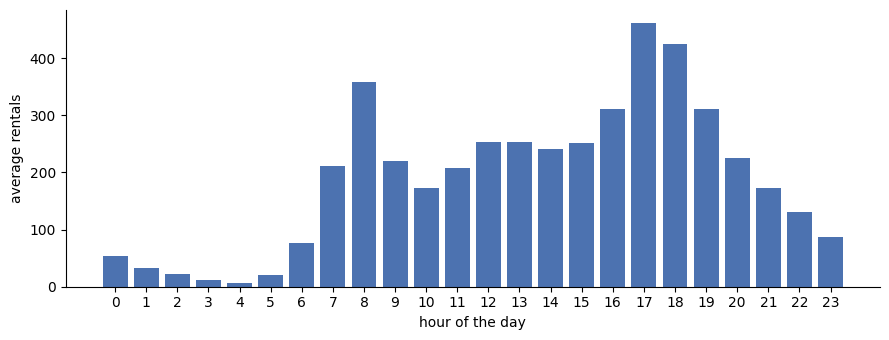

In [16]:
avg_by_hour = df.groupby('hour')['rentals'].mean()

from local_utils import plot_avg_rentals
plot_avg_rentals(avg_by_hour, xlabel='hour of the day')

This single plot already contains real business insight: two sharp peaks, at 8am and 5–6pm — **commuters**. Keep this shape in mind; it will matter when we model.

### ✏️ Exercise 2

a) Compute the average rentals for each type of `weather`. Does the ordering match your intuition?
b) Compute the average rentals on working days vs. non-working days (`workingday`).
c) *Bonus:* find the single busiest hour in the whole dataset — display its full row (*hint:* `.sort_values()` or `.idxmax()` combined with `.loc`).

In [17]:
# --- Exercise 2 ---
avg_by_weather = df.groupby('weather')['rentals'].mean()
avg_by_workingday = df.groupby('workingday')['rentals'].mean()

print(avg_by_weather.round(1))
print(avg_by_workingday.round(1))

# Bonus
busiest_row = df.loc[df['rentals'].idxmax()]
busiest_row

weather
clear              204.9
heavy_rain_snow     74.3
light_rain_snow    111.6
mist               175.2
Name: rentals, dtype: float64
workingday
0    181.4
1    193.2
Name: rentals, dtype: float64


date          2012-09-12
season            summer
year                2012
month                sep
hour                  18
weekday        wednesday
workingday             1
holiday                0
weather            clear
temp                27.1
feels_like          31.1
humidity              44
windspeed           17.0
rentals              977
Name: 14773, dtype: object

**Answer notes.** Clear weather averages ~205 rentals/hour versus ~112 under light rain or snow — weather matters, a lot. Working and non-working days rent *in total* about the same, but as we will see, they do so at very different hours. The busiest hour ever: 5pm on a clear September working day in 2012, with 977 rentals.

**Encoding categories as numbers.** Models compute with numbers; they cannot multiply `'clear'` by a coefficient. The standard fix, seen in class, is **dummy (one-hot) variables**: one 0/1 column per category. In pandas this is a one-liner, `pd.get_dummies`:

In [18]:
pd.get_dummies(df[['weather']]).head()

,weather_clear,weather_heavy_rain_snow,weather_light_rain_snow,weather_mist
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,True,False,False,False
4,True,False,False,False


### ✏️ Question 3 *(discussion — no code)*

We will also encode `hour` as 24 dummy variables, even though it is already a number. Look again at the average-rentals-by-hour plot above. **Why not simply keep `hour` as a single numeric feature in a linear model?**

**Answer.** A linear model with `hour` as one numeric feature can only learn "each extra hour adds (or removes) $w$ rentals" — a steadily increasing or decreasing effect. But the true pattern is *bimodal* (peaks at 8h and 17h, a dip at night): no single slope can represent it. With 24 dummies, the model learns a separate effect per hour, at the cost of more parameters — the flexibility/capacity trade-off from week 2, which we will meet again very soon.

In [19]:
df_model = pd.get_dummies(df, columns=['season', 'month', 'hour',
                                       'weekday', 'weather'])
print(f'Before encoding: {df.shape[1]} columns. After: {df_model.shape[1]} columns.')
df_model.head()

Before encoding: 14 columns. After: 60 columns.


,date,year,workingday,holiday,temp,feels_like,humidity,windspeed,rentals,season_fall,...,weekday_monday,weekday_saturday,weekday_sunday,weekday_thursday,weekday_tuesday,weekday_wednesday,weather_clear,weather_heavy_rain_snow,weather_light_rain_snow,weather_mist
0,2011-01-01,2011,0,0,9.8,14.4,81,0.0,16,False,...,False,True,False,False,False,False,True,False,False,False
1,2011-01-01,2011,0,0,9.0,13.6,80,0.0,40,False,...,False,True,False,False,False,False,True,False,False,False
2,2011-01-01,2011,0,0,9.0,13.6,80,0.0,32,False,...,False,True,False,False,False,False,True,False,False,False
3,2011-01-01,2011,0,0,9.8,14.4,75,0.0,13,False,...,False,True,False,False,False,False,True,False,False,False
4,2011-01-01,2011,0,0,9.8,14.4,75,0.0,1,False,...,False,True,False,False,False,False,True,False,False,False


One last connection: pandas is NumPy underneath. `.values` reveals the raw array behind any column or table — this is what scikit-learn will actually compute on (it happily accepts DataFrames directly and does the conversion for us).

In [20]:
df_model['temp'].values[:5]

array([9.8, 9. , 9. , 9.8, 9.8])

<a id='regression'></a>
# Part 3 — Regression: predicting hourly demand

We can now set up the supervised learning problem from week 2: a dataset of pairs $(x_i, y_i)$, where $x_i$ describes hour $i$ (its features) and $y_i$ is the number of rentals during that hour. By convention, the features are collected in a matrix `X` (one row per example — the NumPy convention from Part 1) and the targets in a vector `y`.

In [21]:
X = df_model.drop(columns=['date', 'rentals'])   # everything except the target (and the raw date)
y = df_model['rentals']
print(X.shape, y.shape)

(17379, 58) (17379,)


### 3.1 — Train/test split

The goal of supervised learning is to predict well on data the model has **never seen** (week 2: *generalization*). So we set aside 20% of our data as a **test set**, untouched during training, and used only to estimate performance at the very end.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)   # random_state makes the shuffle reproducible

print(f'{len(X_train)} training examples, {len(X_test)} test examples')

13903 training examples, 3476 test examples


*Remark for the curious:* our rows are consecutive hours, so a random split puts hours in the test set whose immediate neighbours are in the training set — which makes the test slightly optimistic. Proper evaluation of time series (train on the past, test on the future) is a topic of its own; we set it aside today.

### 3.2 — Always start with a baseline

Before any sophisticated model, fit a trivial one: **predict the training-set average for every hour**. Any model that cannot beat this has learned nothing. scikit-learn provides it as `DummyRegressor`.

To measure error we use the **mean squared error (MSE)** from class, and also report its square root (**RMSE**), which lives in the original units. I.e., "we are off by about this many rentals".

In [23]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

baseline = DummyRegressor(strategy='mean') # predicts the mean of train set for each test example
baseline.fit(X_train, y_train)

# a small helper we will reuse for every model
def rmse(model, X, y):
    return mean_squared_error(y, model.predict(X)) ** 0.5

print(f'Baseline — train RMSE: {rmse(baseline, X_train, y_train):.1f} rentals')
print(f'Baseline —  test RMSE: {rmse(baseline, X_test, y_test):.1f} rentals')

Baseline — train RMSE: 182.2 rentals
Baseline —  test RMSE: 178.0 rentals


Off by ~180 rentals on a typical hour: that is our number to beat.

### 3.3 — The scikit-learn pattern

You just saw it with the baseline. **Every** model in scikit-learn follows the same three steps:

```python
model = SomeModel()          # 1. create (choosing hyperparameters)
model.fit(X_train, y_train)  # 2. learn parameters from training data
model.predict(X_new)         # 3. predict on new data
```

The rest of this tutorial — and a large part of applied machine learning — is variations on these three lines. Let's use them on the linear regression from class:

In [24]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, y_train)

print(f'Linear regression — train RMSE: {rmse(reg, X_train, y_train):.1f}')
print(f'Linear regression —  test RMSE: {rmse(reg, X_test, y_test):.1f}')

Linear regression — train RMSE: 101.9
Linear regression —  test RMSE: 100.4


Two observations:
- Test RMSE drops from ~178 to ~100: our features carry real signal.
- Train and test errors are nearly equal: **no overfitting** here. With ~13,900 training examples for 59 parameters, the model does not have enough capacity to memorize (week 2's bias/variance discussion).

We can look at the predictions directly:

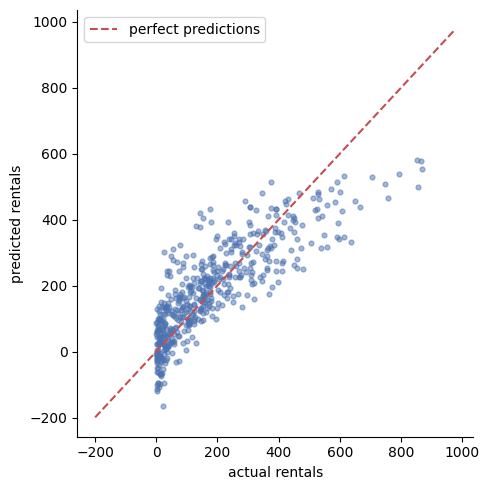

In [25]:
from local_utils import plot_predictions
plot_predictions(y_test, reg.predict(X_test))

### 3.4 — What did the model learn?

A linear model predicts $f(x) = w \cdot x + b$. The learned weights $w$ (`reg.coef_`) contain the learned information. When analyzing them, careful that they can only be compared when features live on comparable scales, and each is read "all else being equal".

In [26]:
coefs = pd.Series(reg.coef_, index=X.columns).sort_values()
print('Most negative effects:')
print(coefs.head(5).round(1))
print()
print('Most positive effects:')
print(coefs.tail(5).round(1))

Most negative effects:
hour_4   -165.1
hour_3   -162.7
hour_2   -152.7
hour_5   -147.1
hour_1   -142.3
dtype: float64

Most positive effects:
hour_16    100.4
hour_19    110.5
hour_8     190.8
hour_18    217.1
hour_17    257.3
dtype: float64


The model has rediscovered, from data alone, what most operations teams likely know: rush hours (17h, 18h, 8h) boost demand, night hours and bad weather lower it. This interpretability is a major reason linear models remain everywhere in business analytics (i.e., non-linear models can be more challenging or near impossible to interpret).

Let's also sanity-check a single prediction against reality:

In [27]:
i = 3                              # pick any test example
row_id = X_test.index[i]

print('The hour we are predicting:')
print(df.loc[row_id, ['date', 'weekday', 'hour', 'weather', 'temp']])
print()
print(f'Actual rentals   : {y_test.iloc[i]}')
print(f'Model prediction : {reg.predict(X_test.iloc[[i]])[0]:.0f}')

The hour we are predicting:
date       2012-05-29
weekday       tuesday
hour               19
weather         clear
temp             32.0
Name: 12230, dtype: object

Actual rentals   : 526
Model prediction : 432


### ✏️ Exercise 4

According to the model, how many additional rentals per hour does one extra degree Celsius bring, all else being equal? Extract the answer from `coefs`, and check that its sign matches the intuition you built in Exercise 2.

In [28]:
# --- Exercise 4 ---
temp_effect = coefs['temp']
print(f'Each extra degree Celsius is associated with {temp_effect:.1f} additional rentals per hour.')
# The sign is positive, consistent with warm hours renting more —
# though remember: this is a correlation the model found, "all else being equal".

Each extra degree Celsius is associated with 2.7 additional rentals per hour.


### 3.5 — Overfitting: what if the service had just launched?

Our model behaves well partly because data is abundant. Companies are rarely so lucky at the start. Suppose the service had launched a week ago, and we had only 168 hours of data to work with:

In [29]:
X_small, y_small = X_train[:168], y_train[:168]   # one week of hours

reg_small = LinearRegression()
reg_small.fit(X_small, y_small)

print(f'train RMSE (on the 168 hours): {rmse(reg_small, X_small, y_small):.1f}')
print(f' test RMSE                   : {rmse(reg_small, X_test, y_test):.1f}')

train RMSE (on the 168 hours): 85.3
 test RMSE                   : 123.4


A large gap has appeared: much better on the training data than on new data. This is **overfitting**, exactly as defined in week 2 — the model has partly memorized the noise of its 168 examples instead of learning only the general pattern.

### ✏️ Question 5 *(discussion — no code)*

How many parameters does this linear model have? (*Hint:* don't forget the intercept.) Compare that number to the number of training examples. Why does that comparison explain what we just observed?

**Answer.** One weight per feature column (58) plus the intercept $b$: **59 parameters**, estimated from only 168 examples — roughly one parameter per three data points. With so many degrees of freedom, the model can bend itself to fit the training set very closely — including its noise — which is precisely the high-variance regime of the bias/variance trade-off.

### 3.6 — Regularization to the rescue

Week 2's remedy: **penalize large weights**. *Ridge regression* is linear regression plus an L2 penalty $\alpha \sum_j w_j^2$ added to the training objective. The hyperparameter $\alpha$ sets the strength: $\alpha = 0$ recovers plain linear regression; $\alpha \to \infty$ shrinks all weights towards 0 (and the model towards the baseline).

In [30]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)
ridge.fit(X_small, y_small)

print(f'Ridge (alpha=1) — train RMSE: {rmse(ridge, X_small, y_small):.1f}')
print(f'Ridge (alpha=1) —  test RMSE: {rmse(ridge, X_test, y_test):.1f}')

Ridge (alpha=1) — train RMSE: 87.9
Ridge (alpha=1) —  test RMSE: 118.6


Train error got a little *worse*, test error got *better*. But we picked $\alpha=1$ out of a hat. Let's sweep a range of values and watch both errors:

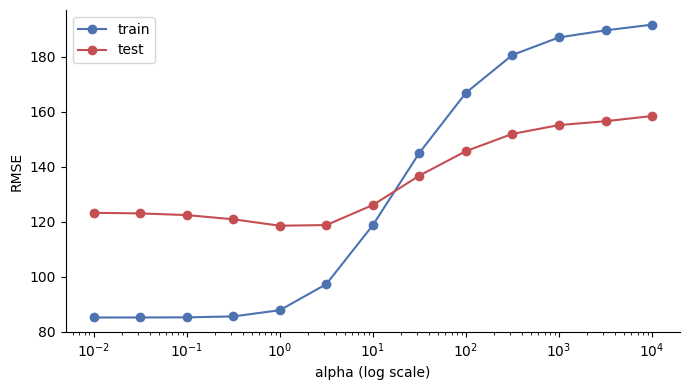

In [31]:
alphas = np.logspace(-2, 4, 13)   # 0.01, ..., 10000 (powers of 10)

train_errors, test_errors = [], []
for a in alphas:
    r = Ridge(alpha=a).fit(X_small, y_small)
    train_errors.append(rmse(r, X_small, y_small))
    test_errors.append(rmse(r, X_test, y_test))

from local_utils import plot_train_test
plot_train_test(alphas, train_errors, test_errors,
                xlabel='alpha (log scale)', ylabel='RMSE', logx=True)

This picture *is* the bias/variance trade-off, drawn by real data:

- **Left** (tiny $\alpha$): low train error, higher test error — overfitting (high variance).
- **Right** (huge $\alpha$): both errors high — underfitting (high bias). (With $\alpha$ enormous, all weights are crushed to zero and we are back to... the baseline.)
- The test error is U-shaped; the sweet spot lies in the middle, around $\alpha \approx 1$.

*(Technical aside: hyperparameter values are conventionally swept in powers of 10, hence `np.logspace`.)*

### 3.7 — Choosing $\alpha$ honestly: cross-validation

We just chose $\alpha$ by looking at **test** error — a methodological sin. The test set must stay in the vault until the final evaluation; otherwise it silently becomes part of training and stops being an honest measure (week 2: *model validation*).

The correct procedure is **cross-validation within the training data**. scikit-learn automates it: `RidgeCV` tries each candidate $\alpha$ by internal cross-validation on the training set and keeps the best.

### ✏️ Exercise 6

Fit a `RidgeCV` (already imported below) on the *small* training set, passing it our grid `alphas`. Print the $\alpha$ it selects (attribute `.alpha_`) and its test RMSE.

In [32]:
# --- Exercise 6 ---
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=alphas)
ridge_cv.fit(X_small, y_small)

print(f'alpha selected by cross-validation: {ridge_cv.alpha_}')
print(f'test RMSE: {rmse(ridge_cv, X_test, y_test):.1f}')
# Cross-validation lands on the same alpha as our sweep —
# without ever touching the test set. That is the whole point.

alpha selected by cross-validation: 1.0
test RMSE: 118.6


Finally, back to the **full** training set:

In [33]:
ridge_cv_full = RidgeCV(alphas=alphas)
ridge_cv_full.fit(X_train, y_train)

print(f'alpha selected: {ridge_cv_full.alpha_}')
print(f'test RMSE: {rmse(ridge_cv_full, X_test, y_test):.1f}')

alpha selected: 1.0
test RMSE: 100.4


With abundant data, regularization barely changes anything (test RMSE ~100 either way) — the data itself constrains the model. A lesson worth remembering: **more data is often the best regularizer.**

### Where we stand

| Model | Test RMSE |
|---|---|
| Baseline (predict the mean) | ~178 |
| Linear regression (full data) | ~100 |
| RidgeCV (full data) | ~100 |
| Linear regression (one week of data) | ~123 |
| RidgeCV (one week of data) | ~119 |

<a id='classification'></a>
# Part 4 — Classification: flagging high-demand hours

The operations team's second request: a system that flags, in advance, the hours where demand will be **high** — say, at least 300 rentals (roughly the top quarter of hours) — so trucks can pre-position bikes.

The target is now a **class** (high demand: yes/no) rather than a quantity: this is *classification*, the setting of week 3. The features `X` don't change; only `y` does.

In [34]:
y_class = (df['rentals'] >= 300).astype(int)   # 1 = high demand, 0 = normal
print(f'Share of high-demand hours: {y_class.mean():.1%}')

X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42)

Share of high-demand hours: 22.6%


### 4.1 — The baseline, again

The natural error measure is now **accuracy**: the proportion of correct predictions. And once again we start with a trivial model: **always predict the most common class** ("normal demand").

In [35]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_clf = DummyClassifier(strategy='most_frequent')
baseline_clf.fit(X_train, yc_train)

acc = accuracy_score(yc_test, baseline_clf.predict(X_test))
print(f'Baseline accuracy: {acc:.1%}')

Baseline accuracy: 78.5%


**78.5% accuracy while being completely useless** — it never flags a single high-demand hour! This is the classic trap of accuracy with imbalanced classes. Two takeaways: always compare to this baseline, and always look *where* the errors are (we will, in a moment).

### 4.2 — Logistic regression

Week 3's linear classifier: compute a linear score $w \cdot x + b$, squash it through the logistic (sigmoid) function into a probability, predict "high demand" when that probability exceeds 50%. Same three lines as always:

In [36]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000)   # allow the optimizer enough iterations
log_reg.fit(X_train, yc_train)

print(f'train accuracy: {accuracy_score(yc_train, log_reg.predict(X_train)):.1%}')
print(f' test accuracy: {accuracy_score(yc_test, log_reg.predict(X_test)):.1%}')

train accuracy: 85.4%
 test accuracy: 85.8%


A solid jump above the baseline. And because the model outputs *probabilities*, the business can tune its own trade-off — send trucks only when it is very sure, for example:

In [37]:
probs = log_reg.predict_proba(X_test[:5])
pd.DataFrame(probs.round(3), columns=['P(normal)', 'P(high demand)'])

,P(normal),P(high demand)
0,0.088,0.912
1,0.969,0.031
2,0.995,0.005
3,0.177,0.823
4,1.000,0.000


### 4.3 — The confusion matrix: where are the errors?

For a classifier, a single accuracy number hides the most important business information: **which kind** of mistakes it makes. The confusion matrix crosses actual vs. predicted classes (here computed with the pandas `crosstab` you now know):

In [38]:
y_pred = log_reg.predict(X_test)
pd.crosstab(yc_test.values, y_pred,
            rownames=['actual'], colnames=['predicted'])

predicted,0,1
actual,,
0,2532,197
1,298,449


The two kinds of errors have very different costs:
- **Missed high-demand hours** (actual 1, predicted 0): stations run empty, customers walk away.
- **False alarms** (actual 0, predicted 1): trucks roll out for nothing.

Accuracy weighs them equally; your operations team almost certainly does not. Quantifying this distinction (precision, recall) is standard practice — keep the vocabulary in mind for your projects.

### 4.4 — k nearest neighbours (and why scale matters)

Week 3's most intuitive classifier: to classify a new hour, find the $k$ most *similar* hours in the training data and take a majority vote.

"Similar" means *close in distance* — and that creates a subtlety. Our features live on wildly different scales: humidity runs 0–100 while dummy variables are 0/1. Left as is, the distance is dominated by whichever features have the biggest numbers. The standard fix is to **standardize** each feature (subtract its mean, divide by its standard deviation), using `StandardScaler`. Note that the scaler is fit on the *training* data only — the same no-peeking principle as cross-validation.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)                        # learn means and sds on TRAIN only
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_s, yc_train)

print(f'k=1 — train accuracy: {accuracy_score(yc_train, knn1.predict(X_train_s)):.1%}')
print(f'k=1 —  test accuracy: {accuracy_score(yc_test, knn1.predict(X_test_s)):.1%}')

k=1 — train accuracy: 100.0%


k=1 —  test accuracy: 89.5%


### ✏️ Question 7 *(discussion — no code)*

Why is the training accuracy of 1-nearest-neighbour **exactly 100%**? What does this tell you about the model?

**Answer.** Each training point's nearest neighbour in the training set is *itself* (distance 0), so it is always classified by its own label. Note: this is the way sklearn implements it. The model perfectly memorizes the training data — the most extreme form of overfitting. That its test accuracy is nonetheless decent tells us the classes are fairly well separated in feature space; but we can do better with a larger $k$, which averages out noise.

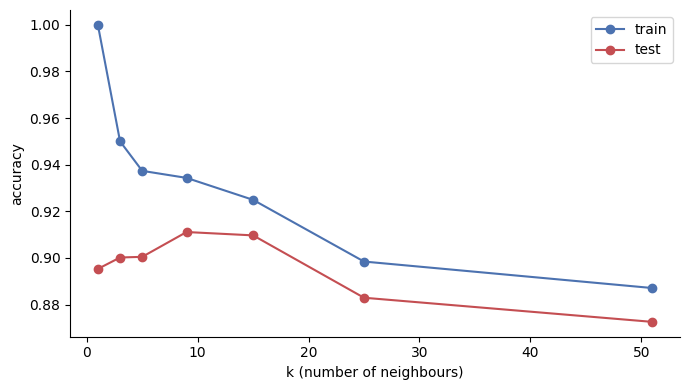

In [41]:
ks = [1, 3, 5, 9, 15, 25, 51]

train_accs, test_accs = [], []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, yc_train)
    train_accs.append(accuracy_score(yc_train, knn.predict(X_train_s)))
    test_accs.append(accuracy_score(yc_test, knn.predict(X_test_s)))

plot_train_test(ks, train_accs, test_accs, xlabel='k (number of neighbours)',
                ylabel='accuracy')

The same story as the $\alpha$ sweep of Part 3, mirrored (higher is better now): small $k$ overfits, large $k$ underfits, the sweet spot is in between (~$k=15$, about 91% — our best model so far). $k$ plays for kNN the role $\alpha$ played for ridge: **a knob controlling model capacity**, to be tuned by validation.

### ✏️ Exercise 8

Fit a kNN with $k = 15$ on the **unscaled** features (`X_train` instead of `X_train_s`) and compare its test accuracy. How much did standardization matter?

In [42]:
# --- Exercise 8 ---
knn_unscaled = KNeighborsClassifier(n_neighbors=15)
knn_unscaled.fit(X_train, yc_train)

acc_unscaled = accuracy_score(yc_test, knn_unscaled.predict(X_test))
print(f'test accuracy without scaling: {acc_unscaled:.1%}')
# ~80% vs ~91%: without scaling, the distance is dominated by
# large-scale features (humidity, temperature) and kNN barely beats the baseline.

test accuracy without scaling: 80.2%


### 4.5 — Naive Bayes

Week 3's probabilistic classifier: model $p(x \mid y)$ for each class under the "naive" assumption that features are independent given the class, then classify with Bayes' rule. Its virtues are speed and simplicity.

scikit-learn offers one variant per type of feature (Gaussian for continuous, Bernoulli for binary, Categorical for categories). Most of our columns are 0/1 dummies, so we use `BernoulliNB` on just those:

In [43]:
from sklearn.naive_bayes import BernoulliNB

numeric_cols = ['temp', 'feels_like', 'humidity', 'windspeed', 'year']
Xb_train = X_train.drop(columns=numeric_cols)   # keep only the 0/1 columns
Xb_test = X_test.drop(columns=numeric_cols)

nb = BernoulliNB()
nb.fit(Xb_train, yc_train)

print(f'train accuracy: {accuracy_score(yc_train, nb.predict(Xb_train)):.1%}')
print(f' test accuracy: {accuracy_score(yc_test, nb.predict(Xb_test)):.1%}')

train accuracy: 84.3%
 test accuracy: 83.2%


~83% while training in milliseconds — remarkably close to logistic regression, even though the independence assumption is plainly false here (hour and workingday, season and month...). This resilience is why week 3 presented Naive Bayes as a strong, simple baseline.

*Bonus for the curious:* try `GaussianNB` on **all** the features instead. You will get ~59% — worse than the do-nothing baseline! A Gaussian is an absurd model for 0/1 features; a useful reminder that a model's assumptions must roughly match the data.

### Where we stand

| Classifier | Test accuracy |
|---|---|
| Baseline (always "normal") | 78.5% |
| Naive Bayes (Bernoulli, dummies only) | ~83% |
| Logistic regression | ~86% |
| kNN ($k=15$, standardized) | ~91% |

A closing question worth pondering: why does kNN beat logistic regression here? One answer: kNN can capture **interactions** — e.g., 8am is a rush hour *only on working days* — that a linear score cannot express... unless we build those features ourselves. Which brings us to the challenge.

<a id='challenge'></a>
# Part 5 — ✏️ Challenge: beat our best model

Your turn to be the analyst. **Goal: beat the regression test RMSE of ~100** obtained by `RidgeCV` on the full data (Part 3.7).

You may change anything upstream of the model — this is called **feature engineering**, and it is where *your* domain knowledge (the comparative advantage of a business background!) enters machine learning. Ideas:

- **Interactions:** the hourly pattern differs between working and non-working days. Create a combined categorical feature, e.g. `df['hour'].astype(str) + '_' + df['workingday'].astype(str)`, and let `get_dummies` encode it.
- Nonlinear transforms of numeric features: `temp` squared (comfort peaks at mild temperatures?), temperature bins...
- Anything Exercise 2-style exploration suggests to you.

**Rules of the game:** make all your choices using the training data; evaluate on the test set only once, at the end. Keep `random_state=42` in the split so results are comparable across the class.

In [44]:
# --- Exercise 9 (challenge) ---
df_new = df.copy()

# One high-impact feature: the hour x workingday interaction.
df_new['hour_type'] = df_new['hour'].astype(str) + '_' + df_new['workingday'].astype(str)

df_new_model = pd.get_dummies(df_new, columns=['season', 'month', 'hour',
                                               'weekday', 'weather', 'hour_type'])
X_new = df_new_model.drop(columns=['date', 'rentals'])

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42)

challenge_model = RidgeCV(alphas=alphas)
challenge_model.fit(Xn_train, yn_train)

print(f'test RMSE: {rmse(challenge_model, Xn_test, yn_test):.1f}  (target: below 100)')

test RMSE: 77.3  (target: below 100)


**Answer notes.** The single interaction `hour × workingday` brings the test RMSE from ~100 down to ~77 — a larger improvement than anything we obtained by tuning models. The reason: a linear model cannot multiply features together on its own; "8am matters *only on working days*" is inexpressible until we hand it that combined feature. The general lesson is worth framing on your wall: **in applied machine learning, better features routinely beat better models.**

<a id='epilogue'></a>
# Epilogue — A glimpse of next week *(optional)*

We just saw that hand-crafting the right feature (an interaction) beats model tuning. Next week's topic — **neural networks** — offers a different deal: models that *learn* nonlinearities and interactions themselves, directly from the raw features, at the price of interpretability and more hyperparameters.

As a teaser, here is one — with the exact same three lines you now know by heart:

In [45]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(hidden_layer_sizes=(50,), early_stopping=True,
                  max_iter=1000, random_state=0)
nn.fit(scaler.transform(X_train), y_train)     # neural nets also prefer standardized inputs

print(f'Neural network — test RMSE: {rmse(nn, scaler.transform(X_test), y_test):.1f}')

Neural network — test RMSE: 44.3


Better than everything above — *without* us engineering a single feature. How, and at what cost? See you Wednesday.

# Wrap-up

You can now, on a real dataset:
- load and explore a data table with **pandas** (select, filter, `groupby`);
- prepare features for modelling (`get_dummies`), understanding the arrays underneath (**NumPy**);
- follow the universal **scikit-learn** pattern — `fit`, `predict`, evaluate — for regression and classification;
- practice the core methodology from class: train/test splits, baselines, over/underfitting, regularization, hyperparameter tuning by cross-validation, confusion matrices.

That toolkit covers a surprising share of real-world applied machine learning — and it is everything you need for the course project.

## References

- scikit-learn: [documentation](https://scikit-learn.org/stable/), [tutorials](https://scikit-learn.org/stable/tutorial/index.html)
- pandas: [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
- NumPy: [quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- Dataset: Fanaee-T, H., & Gama, J. (2014). *Event labeling combining ensemble detectors and background knowledge.* Progress in Artificial Intelligence. Data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset) (CC BY 4.0).